# XOPT - PATH PROBLEM IN MAX-K-CUT

This notebook uses three fixed solutions from the geometric `att48` instance, with `p = 5`, to demonstrate the problem of **disconnected solutions**, that is, solutions without a direct transition trajectory between them in the long-term memory. This phenomenon is analyzed in the context of applying **max-k-cut** to identify alternative facilities to those present in the best solution found.

### PROJECT SETUP

In [1]:
import warnings

import networkx          as nx
import numpy             as np
import pandas            as pd
import matplotlib.pyplot as plt

from IPython.display import display


warnings.filterwarnings('ignore', category=UserWarning)

In [2]:
from lib.paths  import find_project_root

from lib.tsplib import TSPLIBInstanceSpec          , \
                       load_tsplib_instance        , \
                       assignment_profile          , \
                       extract_geometric_structures
from lib.plots  import plot_solution_map      , \
                       plot_max_k_cut_clusters


PROJECT_ROOT = find_project_root()

print(f'Project root = {PROJECT_ROOT}')

Project root = /home/rei-luisinho/xopt


### EXPERIMENT CONFIGURATION

In [3]:
P = 5

FIXED_SOLUTIONS_ONE_BASED = [
    (10, 48, 23, 9, 6 ),
    (10, 5 , 11, 1, 6 ),
    (10, 5 , 11, 1, 28),
]

TOP_FRACTION       = 1.0
MAX_K_CUT_RESTARTS = 40
MAX_K_CUT_MAX_ITER = 2000
GLOBAL_SEED        = 42

ATT48_SPEC = TSPLIBInstanceSpec(
    name             ='att48',
    dimension        =48     ,
    edge_weight_type ='ATT'  ,
    p                =P,

    url              ='https://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/att48.tsp.gz'                 ,
    raw_path         =PROJECT_ROOT / 'notebooks' / 'experiments_sbpo' / 'artifacts' / 'tsplib_tsp' / 'att48.tsp',
)


print(f'TSPLIB instance {ATT48_SPEC.name} (dimension = {ATT48_SPEC.dimension}, p = {ATT48_SPEC.p})')

TSPLIB instance att48 (dimension = 48, p = 5)


### LOAD INSTANCE

In [4]:
instance = load_tsplib_instance(ATT48_SPEC)

fixed_solutions = [
    tuple(int(node) - 1 for node in solution)
    for solution in FIXED_SOLUTIONS_ONE_BASED
]

print(f'Loaded {instance.name} with {len(instance.points)} nodes and p={instance.p}.')

Loaded tsplib_att48_p5 with 48 nodes and p=5.


### MAX-K-CUT HELPERS

In [5]:
def binary_facility_vector(
    n: int, facilities: tuple[int, ...]
) -> np.ndarray:
    vector = np.zeros(n, dtype=np.int8)

    vector[list(facilities)] = 1

    return vector


def result_for_facilities(
    instance,
    facilities     : tuple[int, ...],
    solution_index : int            ,
) -> dict[str, object]:
    selected = tuple(
        sorted(
            int(value) for value in facilities
        )
    )

    cost, assignments, _, _, _ = assignment_profile(instance, selected)

    return {
        'instance'             : instance,

        'solution_index'       : int (solution_index                               ),
        'facilities_one_based' : list(FIXED_SOLUTIONS_ONE_BASED[solution_index - 1]),

        'summary'               : {
            'n'                 : len(instance.points),
            'p'                 :     instance.p      ,

            'tspmed_cost'       : float(cost),
            'tspmed_facilities' : [node + 1 for node in selected],
            'long_term_mem'     : len(FIXED_SOLUTIONS_ONE_BASED ),
        },

        'details'              : {}         ,
        'selected'             : selected   ,
        'assignments'          : assignments,
        'runtime'              : 0.0,
    }

In [6]:
top_solution_results = [
    result_for_facilities(instance, facilities, solution_index)
    for solution_index, facilities in enumerate(fixed_solutions, start=1)
]

long_term_memory = [
    {
        'cost'       : solution_result['summary']['tspmed_cost'],
        'facilities' : binary_facility_vector(
            len(instance.points), solution_result['selected'],
        ).tolist(),
    }
    for solution_result in top_solution_results
]

result = min(
    top_solution_results,
    key=lambda solution_result: solution_result['summary']['tspmed_cost'],
).copy()

result['details'] = {'long_term_memory': long_term_memory}

result['structures'] = extract_geometric_structures(
    result,
    top_fraction    =TOP_FRACTION      ,
    max_cut_restarts=MAX_K_CUT_RESTARTS,
    max_cut_max_iter=MAX_K_CUT_MAX_ITER,
    seed            =GLOBAL_SEED       ,
)

### PATH PROBLEM IN MAX-K-CUT

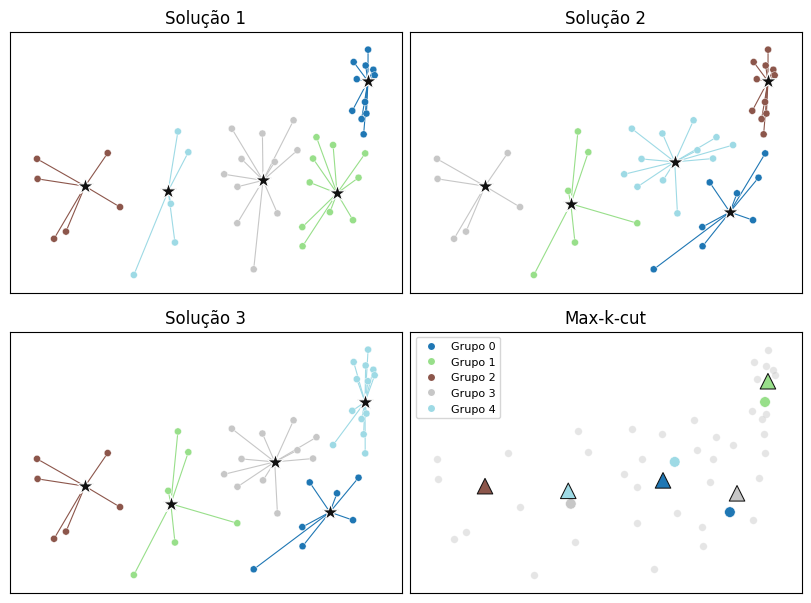

In [7]:
fig, axes = plt.subplots(
    2, 2, figsize=(8, 6), constrained_layout=True
)

for ax, solution_result in zip(axes.flat[:3], top_solution_results):
    plot_solution_map(solution_result, ax=ax, seed=GLOBAL_SEED)

    ax.set_title(
        f'Solução {solution_result["solution_index"]}'
    )

plot_max_k_cut_clusters(
    result, ax=axes[1, 1], seed=GLOBAL_SEED
)
axes[1, 1].set_title('Max-k-cut')

plt.show()

### CO-OCCURRENCE GRAPH

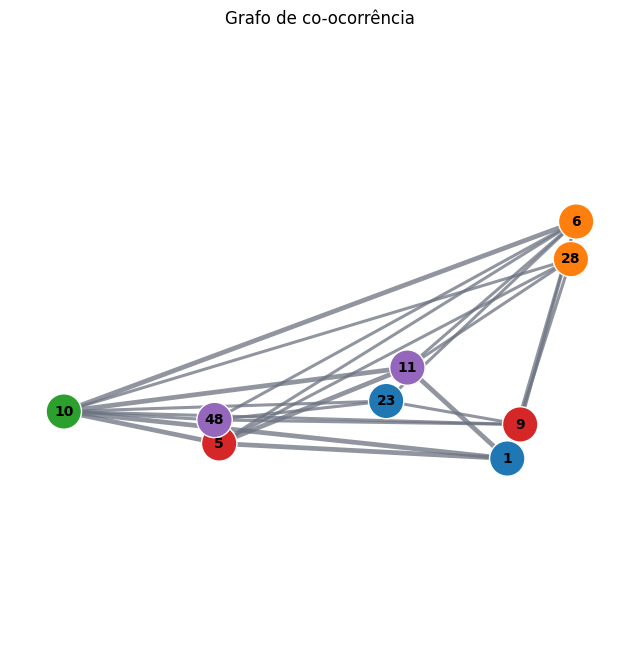

In [8]:
adjacency     = result['structures']['adjacency'    ]
active_nodes  = result['structures']['active_nodes' ]
labels_maxcut = result['structures']['labels_maxcut']

cooccurrence_graph = nx.Graph()

cooccurrence_graph.add_nodes_from(
    active_nodes.astype(int).tolist()
)

rows, cols = np.where(np.triu(adjacency, k=1) > 0)
for row, col in zip(rows.tolist(), cols.tolist()):
    u = int(active_nodes[row])
    v = int(active_nodes[col])

    cooccurrence_graph.add_edge(
        u, v, weight=int(adjacency[row, col])
    )


points_by_node = instance.points.set_index('node')

pos = {
    int(node): (
        float(points_by_node.loc[int(node), 'coord_x']),
        float(points_by_node.loc[int(node), 'coord_y']),
    )
    for node in cooccurrence_graph.nodes()
}

group_colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']
node_colors  = [
    group_colors[labels_maxcut[node] % len(group_colors)]
    for node in cooccurrence_graph.nodes()
]

edge_widths = [
    1.0 + 1.2 * cooccurrence_graph.edges[edge]['weight']
    for edge in cooccurrence_graph.edges()
]


fig, ax = plt.subplots(figsize=(8, 8))

nx.draw_networkx_edges(
    cooccurrence_graph,
    pos               ,
    width     =edge_widths,
    edge_color='#6b7280',
    alpha=0.75,
    ax   =ax  ,
)

nx.draw_networkx_nodes(
    cooccurrence_graph,
    pos               ,
    node_color=node_colors,
    node_size =650        ,
    edgecolors='white'    ,
    linewidths=1.0,
    ax        =ax ,
)

nx.draw_networkx_labels(
    cooccurrence_graph,
    pos               ,
    font_size  =10    ,
    font_weight='bold',
    ax         =ax    ,
    labels={
        node : str(node + 1)
        for node in cooccurrence_graph.nodes()
    },
)

ax.set_title('Grafo de co-ocorrência')
ax.axis     ('equal')
ax.axis     ('off'  )
plt.show    ()

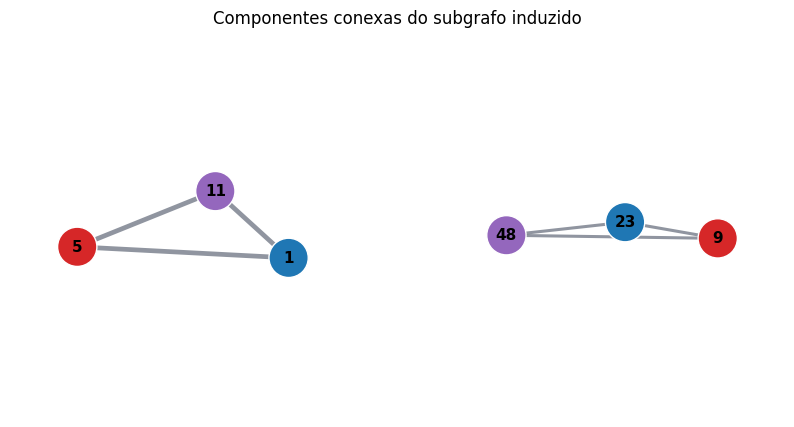

In [9]:
selected_vertices_1based = [1, 5, 11, 9, 23, 48]
selected_vertices        = [v - 1 for v in selected_vertices_1based]

subgraph = cooccurrence_graph.subgraph(selected_vertices).copy()

components = list  (nx.connected_components(subgraph))
components = sorted(components, key=len, reverse=True)

pos_components = {}

x_offsets     = [-3.0, 3.0]
spread_factor = 3.0

for comp_idx, component in enumerate(components[:2]):
    component = list(component)

    xs = np.array([pos[node][0] for node in component])
    ys = np.array([pos[node][1] for node in component])

    x_center = xs.mean()
    y_center = ys.mean()

    x_range = xs.max() - xs.min()
    y_range = ys.max() - ys.min()

    scale = max(x_range, y_range)
    if scale == 0:
        scale = 1.0

    for node in component:
        x, y = pos[node]

        pos_components[node] = (
            spread_factor * (x - x_center) / scale + x_offsets[comp_idx],
            spread_factor * (y - y_center) / scale                      ,
        )

node_colors_subgraph = [group_colors[labels_maxcut[node] % len(group_colors)] for node in subgraph.nodes()]
edge_widths_subgraph = [1.0 + 1.2 * subgraph.edges[edge]['weight']            for edge in subgraph.edges()]


fig, ax = plt.subplots(figsize=(10, 5))

nx.draw_networkx_edges(
    subgraph      ,
    pos_components,
    width     =edge_widths_subgraph,
    edge_color='#6b7280'         ,
    alpha=0.75,
    ax   =ax  ,
)

nx.draw_networkx_nodes(
    subgraph      ,
    pos_components,
    node_color=node_colors_subgraph,
    node_size =800    ,
    edgecolors='white',
    linewidths=1.0    ,
    ax        =ax     ,
)

nx.draw_networkx_labels(
    subgraph      ,
    pos_components,
    font_size  =11    ,
    font_weight='bold',
    ax         =ax    ,
    labels={
        node : str(node + 1)
        for node in subgraph.nodes()
    },
)

ax.set_title('Componentes conexas do subgrafo induzido')
ax.axis     ('equal')
ax.axis     ('off'  )
plt.show    ()

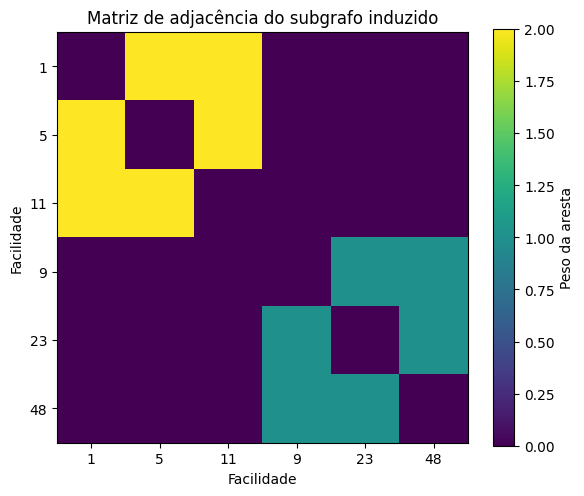

In [10]:
node_to_idx = {
    int(node) : idx
    for idx, node in enumerate(active_nodes)
}

selected_indices = [
    node_to_idx[node]
    for node in selected_vertices
    if  node in node_to_idx
]

sub_adjacency = adjacency[np.ix_(selected_indices, selected_indices)]


fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(sub_adjacency)

ax.set_xticks(np.arange(len(selected_vertices_1based)))
ax.set_yticks(np.arange(len(selected_vertices_1based)))

ax.set_xticklabels(selected_vertices_1based)
ax.set_yticklabels(selected_vertices_1based)

ax.set_xlabel('Facilidade')
ax.set_ylabel('Facilidade')
ax.set_title ('Matriz de adjacência do subgrafo induzido')

plt.colorbar(im, ax=ax, label='Peso da aresta')

plt.tight_layout()
plt.show        ()

### SWAP-GRAPH CONNECTIVITY AND MEMORY COMPLETION

In [11]:
def normalize_solution(
    facilities: tuple[int, ...] | list[int]
) -> tuple[int, ...]:
    return tuple(
        sorted(
            int(facility) for facility in facilities
        )
    )


def solution_swap_distance(
    left : tuple[int, ...],
    right: tuple[int, ...],
    p    : int = P,
) -> int:
    return int(p - len(set(left) & set(right)))


def solution_cost_and_assignments(
    instance,
    facilities: tuple[int, ...],
) -> tuple[float, np.ndarray]:
    cost, assignments, _, _, _ = assignment_profile(instance, normalize_solution(facilities))

    return float(cost), assignments


def memory_record_for_solution(instance, facilities: tuple[int, ...]) -> dict[str, object]:
    cost, _ = solution_cost_and_assignments(instance, facilities)

    return {
        'cost'       : cost,
        'facilities' : binary_facility_vector(len(instance.points), facilities).tolist(),
    }


def build_solution_swap_graph(
    solutions: list[tuple[int, ...]],
) -> nx.Graph:
    graph = nx.Graph()

    for index, solution in enumerate(solutions):
        cost, _ = solution_cost_and_assignments(instance, solution)

        graph.add_node(
            index,
            solution=solution,
            cost    =cost    ,
            label   =f'S{index + 1}',
        )

    for left in range(len(solutions)):
        for right in range(left + 1, len(solutions)):
            distance = solution_swap_distance(solutions[left], solutions[right])

            if distance == 1:
                graph.add_edge(left, right, weight=1, distance=distance)

    return graph


def build_component_graph(
    swap_graph: nx.Graph             ,
    solutions : list[tuple[int, ...]],
) -> tuple[nx.Graph, list[list[int]]]:
    components = [
        sorted(component)
        for component in nx.connected_components(swap_graph)
    ]

    components = sorted(
        components, key=lambda component: (component[0], len(component))
    )

    component_graph = nx.Graph()

    for component_index, component_nodes in enumerate(components):
        component_graph.add_node(
            component_index,
            solution_nodes=    component_nodes ,
            size          =len(component_nodes),
        )

    for left_component in range(len(components)):
        for right_component in range(left_component + 1, len(components)):
            best_pair = None

            for left_solution in components[left_component]:
                for right_solution in components[right_component]:
                    distance = solution_swap_distance(
                        solutions[left_solution ],
                        solutions[right_solution],
                    )

                    candidate_pair = (
                        distance,
                        left_solution ,
                        right_solution,
                    )

                    if best_pair is None or candidate_pair < best_pair:
                        best_pair = candidate_pair

            distance, left_solution, right_solution = best_pair

            component_graph.add_edge(
                left_component ,
                right_component,
                weight           =distance      ,
                source_solution  =left_solution ,
                target_solution  =right_solution,
                source_facilities=solutions[left_solution ],
                target_facilities=solutions[right_solution],
                intersection=tuple(
                    sorted(
                        set(solutions[left_solution]) & set(solutions[right_solution])
                    )
                ),
            )

    return component_graph, components


def greedy_swap_path_between_solutions(
    instance,
    start : tuple[int, ...],
    target: tuple[int, ...],
) -> tuple[list[tuple[int, ...]], list[dict[str, object]]]:
    current = normalize_solution(start )
    target  = normalize_solution(target)

    path = [current]
    rows = []

    while current != target:
        current_set = set(current)
        target_set  = set(target )

        remove_options = sorted(current_set - target_set )
        add_options    = sorted(target_set  - current_set)

        candidates = []
        for remove_facility in remove_options:
            for add_facility in add_options:
                candidate = normalize_solution(
                    list((current_set - {remove_facility}) | {add_facility})
                )
                cost, _ = solution_cost_and_assignments(instance, candidate)

                candidates.append(
                    (
                        cost           ,
                        remove_facility,
                        add_facility   ,
                        candidate      ,
                    )
                )

        if not candidates:
            break

        cost, remove_facility, add_facility, next_solution = min(candidates)

        rows.append(
            {
                'step'              : len(rows)       + 1,
                'removed'           : remove_facility + 1,
                'added'             : add_facility    + 1,
                'cost'              : cost,

                'swap_distance_left': solution_swap_distance(next_solution, target),
                'solution'          : [node + 1 for node in next_solution]         ,
            }
        )

        current = next_solution

        path.append(current)

    return path, rows


def result_from_memory_solutions(
    instance,
    memory_solutions: list[tuple[int, ...]],
) -> tuple[dict[str, object], pd.DataFrame]:
    solution_rows  = []
    memory_records = []

    for index, solution in enumerate(memory_solutions, start=1):
        cost, assignments = solution_cost_and_assignments(instance, solution)

        memory_records.append(memory_record_for_solution(instance, solution))
        solution_rows .append(
            {
                'solution_index'       : index      ,
                'selected'             : solution   ,
                'assignments'          : assignments,
                'cost'                 : cost       ,
                'facilities_one_based' : [node + 1 for node in solution],
            }
        )

    best_solution = min(solution_rows, key=lambda row: row['cost'])

    memory_result = {
        'instance'       : instance,
        'solution_index' : best_solution['solution_index'],
        'summary'        : {
            'n'                 : len(instance.points),
            'p'                 : instance.p,
            'tspmed_cost'       : best_solution['cost'],
            'tspmed_facilities' : best_solution['facilities_one_based'],
            'long_term_mem'     : len(memory_records),
        },
        'details'        : {
            'long_term_memory': memory_records,
        },
        'selected'       : best_solution['selected'   ],
        'assignments'    : best_solution['assignments'],
        'runtime'        : 0.0,
    }

    memory_table = pd.DataFrame(
        [
            {
                'solution'   : row['solution_index'      ],
                'cost'       : row['cost'                ],
                'facilities' : row['facilities_one_based'],
            }
            for row in solution_rows
        ]
    )

    return memory_result, memory_table

In [12]:
original_memory_solutions = [
    normalize_solution(solution)
    for solution in fixed_solutions
]

original_swap_graph = build_solution_swap_graph(original_memory_solutions)
original_components = [
    sorted(component)
    for component in nx.connected_components(original_swap_graph)
]
original_is_connected = (
    original_swap_graph.number_of_nodes() <= 1
    or nx.is_connected(original_swap_graph)
)

component_graph, component_nodes = build_component_graph(
    original_swap_graph      ,
    original_memory_solutions,
)

component_mst = nx.minimum_spanning_tree(component_graph, weight='weight')

connected_memory_solutions = list(original_memory_solutions)
solution_origin            = ['original'] * len(connected_memory_solutions)
solution_to_index          = {
    solution: index
    for index, solution in enumerate(connected_memory_solutions)
}
trajectory_rows = []

if not original_is_connected:
    for mst_left, mst_right, edge_data in component_mst.edges(data=True):
        source_solution_index = int(edge_data['source_solution'])
        target_solution_index = int(edge_data['target_solution'])

        path, path_rows = greedy_swap_path_between_solutions(
            instance,
            original_memory_solutions[source_solution_index],
            original_memory_solutions[target_solution_index],
        )

        previous_solution = path[0]
        previous_index    = solution_to_index[previous_solution]

        for path_position, next_solution in enumerate(path[1:], start=1):
            if next_solution not in solution_to_index:
                solution_to_index[next_solution] = len(connected_memory_solutions)

                connected_memory_solutions.append(next_solution)
                solution_origin           .append('adicionada' )

            next_index = solution_to_index[next_solution]

            step_data = path_rows[path_position - 1]
            trajectory_rows.append(
                {
                    'from_solution'        : previous_index + 1,
                    'to_solution'          : next_index     + 1,
                    'removed'              : step_data['removed'           ],
                    'added'                : step_data['added'             ],
                    'cost'                 : step_data['cost'              ],
                    'swap_distance_to_goal': step_data['swap_distance_left'],
                    'solution'             : step_data['solution'          ],
                }
            )

            previous_solution = next_solution
            previous_index    = next_index

new_swap_graph   = build_solution_swap_graph(connected_memory_solutions)
new_is_connected = (
    new_swap_graph.number_of_nodes() <= 1
    or nx.is_connected(new_swap_graph)
)

display(pd.DataFrame(trajectory_rows))

,from_solution,to_solution,removed,added,cost,swap_distance_to_goal,solution
0,1,4,48,5,12865.0,2,"[5, 6, 9, 10, 23]"
1,4,5,23,11,12911.0,1,"[5, 6, 9, 10, 11]"
2,5,2,9,1,12931.0,0,"[1, 5, 6, 10, 11]"


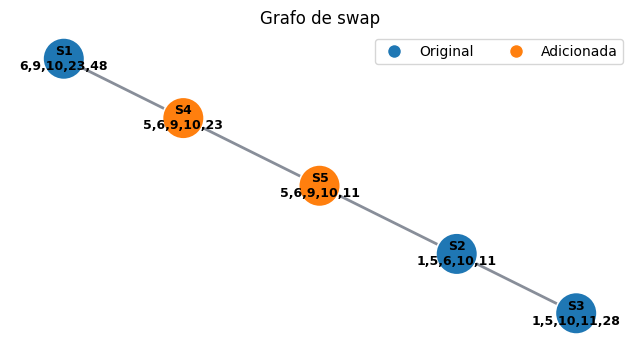

In [13]:
G = nx.Graph()

for idx, sol in enumerate(connected_memory_solutions):
    G.add_node(idx, facilities=[s + 1 for s in sol], origin=solution_origin[idx])

for i in range(len(connected_memory_solutions)):
    for j in range(i + 1, len(connected_memory_solutions)):
        inter = len(
            set(
                connected_memory_solutions[i]) & set(connected_memory_solutions[j]
            )
        )

        if inter == P - 1:
            G.add_edge(i, j)

node_colors = [
    '#1f77b4' if solution_origin[idx] == 'original' else '#ff7f0e'
    for idx in G.nodes()
]

labels = {
    node: 'S{}\n{}'.format(node + 1, ','.join(str(x) for x in G.nodes[node]['facilities']))
    for node in G.nodes()
}

pos = nx.spring_layout(G, seed=GLOBAL_SEED)


fig, ax = plt.subplots(figsize=(8, 4))
nx.draw_networkx_edges (G, pos, ax=ax, edge_color='#6b7280', width    =2.0, alpha     = 0.8)
nx.draw_networkx_nodes (G, pos, ax=ax, node_color=node_colors, node_size=900, linewidths =1.2, edgecolors='white')
nx.draw_networkx_labels(G, pos, ax=ax, labels    =labels     , font_size=9  , font_weight='bold')

legend_handles = [
    plt.Line2D([0], [0], marker='o', color='w', label='Original'  , markerfacecolor='#1f77b4', markersize=10),
    plt.Line2D([0], [0], marker='o', color='w', label='Adicionada', markerfacecolor='#ff7f0e', markersize=10),
]

ax.legend(handles=legend_handles, loc='upper right', ncol=2, frameon=True)

ax.set_title('Grafo de swap')
ax.axis     ('off'          )
plt.show    ()

In [14]:
previous_memory_result , _ = result_from_memory_solutions(instance, original_memory_solutions )
connected_memory_result, _ = result_from_memory_solutions(instance, connected_memory_solutions)

for memory_result in [previous_memory_result, connected_memory_result]:
    memory_result['structures'] = extract_geometric_structures(
        memory_result,
        top_fraction    =TOP_FRACTION      ,
        max_cut_restarts=MAX_K_CUT_RESTARTS,
        max_cut_max_iter=MAX_K_CUT_MAX_ITER,
        seed            =GLOBAL_SEED       ,
    )

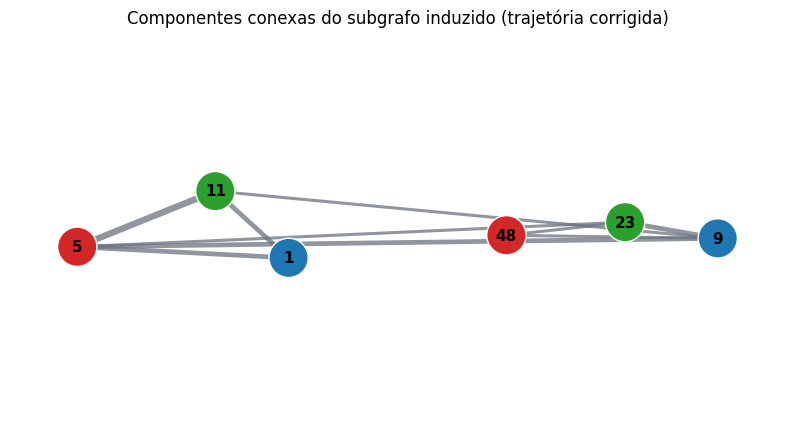

In [15]:
connected_structures    = connected_memory_result['structures']
connected_adjacency     = connected_structures['adjacency'    ]
connected_active_nodes  = connected_structures['active_nodes' ]
connected_labels_maxcut = connected_structures['labels_maxcut']

connected_cooccurrence_graph = nx.Graph()
connected_cooccurrence_graph.add_nodes_from(
    connected_active_nodes.astype(int).tolist()
)

rows, cols = np.where(np.triu(connected_adjacency, k=1) > 0)
for row, col in zip(rows.tolist(), cols.tolist()):
    u = int(connected_active_nodes[row])
    v = int(connected_active_nodes[col])

    connected_cooccurrence_graph.add_edge(
        u, v, weight=int(connected_adjacency[row, col])
    )

connected_pos = {
    int(node): (
        float(points_by_node.loc[int(node), 'coord_x']),
        float(points_by_node.loc[int(node), 'coord_y']),
    )
    for node in connected_cooccurrence_graph.nodes()
}

selected_vertices_1based = [1, 5, 11, 9, 23, 48]
selected_vertices        = [v - 1 for v in selected_vertices_1based]

trajectory_subgraph = connected_cooccurrence_graph.subgraph(selected_vertices).copy()

trajectory_groups_1based = [
    [1, 5, 11],
    [9, 23, 48],
]

trajectory_groups = [
    [v - 1 for v in group if (v - 1) in trajectory_subgraph.nodes()]
    for group in trajectory_groups_1based
]

trajectory_pos_components = {}

x_offsets     = [-3.0, 3.0]
spread_factor = 3.0

for group_idx, group in enumerate(trajectory_groups):
    if not group:
        continue

    xs = np.array([connected_pos[node][0] for node in group])
    ys = np.array([connected_pos[node][1] for node in group])

    x_center = xs.mean()
    y_center = ys.mean()

    x_range = xs.max() - xs.min()
    y_range = ys.max() - ys.min()

    scale = max(x_range, y_range)
    if scale == 0:
        scale = 1.0

    for node in group:
        x, y = connected_pos[node]

        trajectory_pos_components[node] = (
            spread_factor * (x - x_center) / scale + x_offsets[group_idx],
            spread_factor * (y - y_center) / scale,
        )

node_colors_trajectory_subgraph = [
    group_colors[connected_labels_maxcut[node] % len(group_colors)]
    for node in trajectory_subgraph.nodes()
]
edge_widths_trajectory_subgraph = [
    1.0 + 1.2 * trajectory_subgraph.edges[edge]['weight']
    for edge in trajectory_subgraph.edges()
]


fig, ax = plt.subplots(figsize=(10, 5))

nx.draw_networkx_edges(
    trajectory_subgraph      ,
    trajectory_pos_components,
    width     =edge_widths_trajectory_subgraph,
    edge_color='#6b7280'                    ,
    alpha=0.75,
    ax   =ax  ,
)

nx.draw_networkx_nodes(
    trajectory_subgraph      ,
    trajectory_pos_components,
    node_color=node_colors_trajectory_subgraph,
    node_size =800    ,
    edgecolors='white',
    linewidths=1.0    ,
    ax        =ax     ,
)

nx.draw_networkx_labels(
    trajectory_subgraph      ,
    trajectory_pos_components,
    font_size  =11    ,
    font_weight='bold',
    ax         =ax    ,
    labels={
        node : str(node + 1)
        for node in trajectory_subgraph.nodes()
    },
)

ax.set_title('Componentes conexas do subgrafo induzido (trajetória corrigida)')
ax.axis     ('equal')
ax.axis     ('off'  )
plt.show    ()

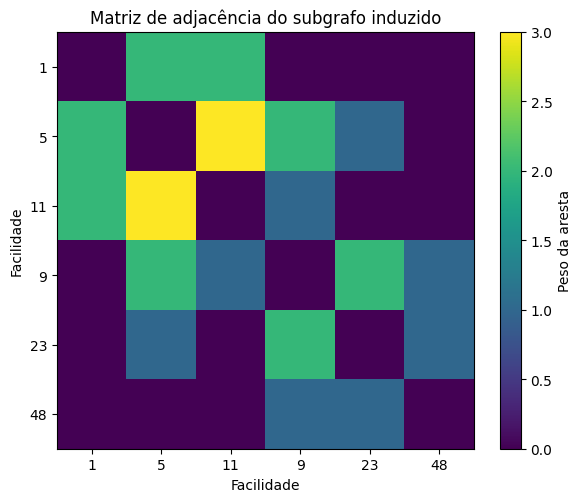

In [16]:
heatmap_vertices_1based = [1, 5, 11, 9, 23, 48]
heatmap_vertices        = [v - 1 for v in heatmap_vertices_1based]

connected_node_to_idx = {
    int(node) : idx
    for idx, node in enumerate(connected_active_nodes)
}

heatmap_pairs = [
    (node, connected_node_to_idx[node])
    for node in heatmap_vertices
    if  node in connected_node_to_idx
]

heatmap_labels_1based = [node + 1 for node, _ in heatmap_pairs]
heatmap_indices       = [idx      for _   , idx in heatmap_pairs]

trajectory_sub_adjacency = connected_adjacency[np.ix_(heatmap_indices, heatmap_indices)]


fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(trajectory_sub_adjacency)

ax.set_xticks(np.arange(len(heatmap_labels_1based)))
ax.set_yticks(np.arange(len(heatmap_labels_1based)))

ax.set_xticklabels(heatmap_labels_1based)
ax.set_yticklabels(heatmap_labels_1based)

ax.set_xlabel('Facilidade')
ax.set_ylabel('Facilidade')
ax.set_title ('Matriz de adjacência do subgrafo induzido')

plt.colorbar(im, ax=ax, label='Peso da aresta')

plt.tight_layout()
plt.show        ()

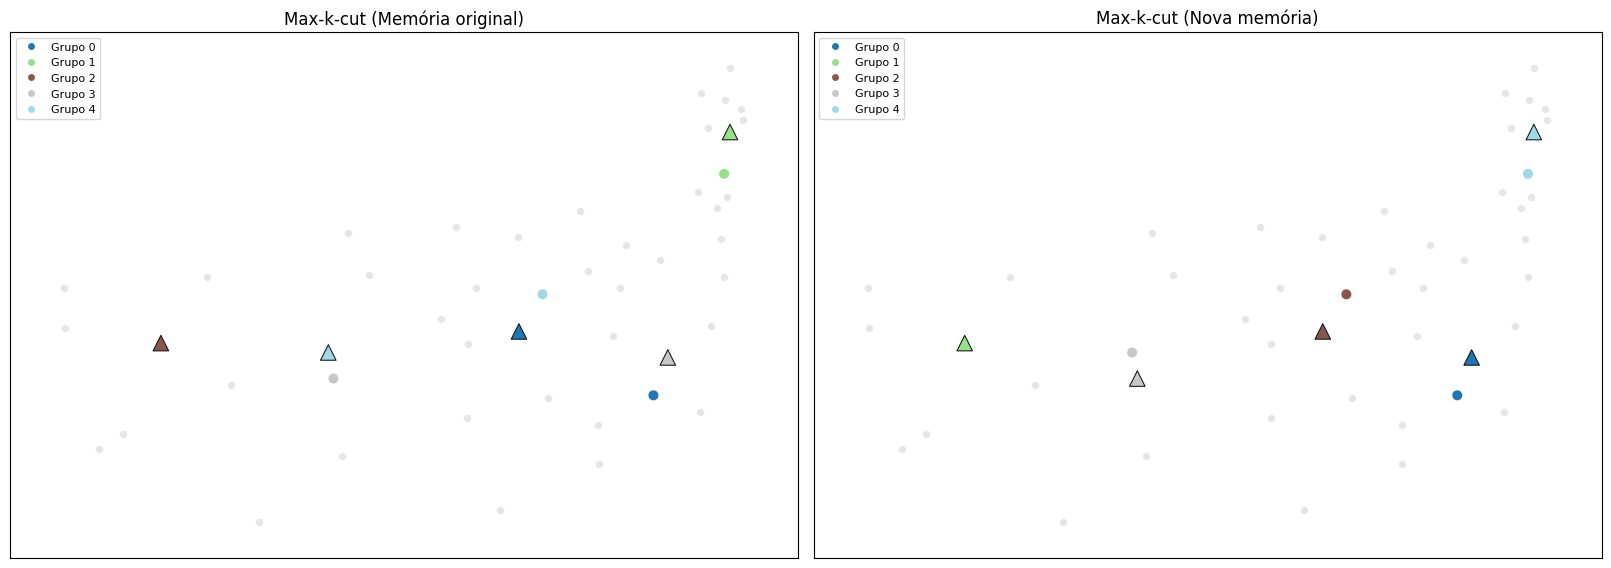

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7), constrained_layout=True)

plot_max_k_cut_clusters(previous_memory_result , ax=axes[0], seed=GLOBAL_SEED)
plot_max_k_cut_clusters(connected_memory_result, ax=axes[1], seed=GLOBAL_SEED)

axes[0].set_title(f'Max-k-cut (Memória original)')
axes[1].set_title(f'Max-k-cut (Nova memória)')

plt.show()